# Week 5 Assignment
## Text Generation using Vanilla RNN, LSTM and GRU
**Name:** Himanshu Singh Gahlot

In this notebook i am building three different sequence models — SimpleRNN, LSTM and GRU — on the same text corpus and comparing how they learn and generate text.

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Section 2 — Text Corpus

i replaced the default corpus with my own paragraph on NLP topics (Task 1). used something related to what we are studying so the generated text would actually make sense to read.

In [23]:
corpus = '''
natural language processing enables machines to understand human language
word embeddings capture semantic meaning of words in vector space
attention mechanisms allow models to focus on relevant parts of the input
transformers have revolutionized the field of natural language understanding
recurrent models process sequences step by step to learn patterns
language models predict the next token based on previous context
'''

corpus = corpus.strip().lower()
print(corpus[:200])

natural language processing enables machines to understand human language
word embeddings capture semantic meaning of words in vector space
attention mechanisms allow models to focus on relevant parts


## Section 3 — Tokenization and Sequence Creation

converting text into integer tokens and creating n-gram sequences. each row in X is the input and y is the next word the model should predict.

In [24]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 47
X shape: (54, 11)
y shape: (54,)


## Section 4 — Building the Three Models

building all three models with the same structure so the comparison is fair. embedding dimension changed from 32 to 64 (Task 2) and hidden units from 64 to 128 (Task 4) in all three.

In [25]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM

LSTM has three gates — input, forget and output. this helps it remember or forget things selectively which makes it better for longer sequences.

In [26]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 3 — GRU

GRU is like a lighter version of LSTM with only two gates — reset and update. trains faster and uses less memory, usually gets similar results.

In [27]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

all three models above have embedding=64 and hidden units=128, so tasks 2 and 4 are done in the model definitions itself

## Section 5 — Training All Three Models

training all three on the same data and same number of epochs so its a fair comparison. increased epochs to 200 (Task 3) — the extra training helps especially for LSTM which was still improving around epoch 100.

In [28]:
EPOCHS = 200

rnn_history  = rnn_model.fit(X,  y, epochs=EPOCHS, verbose=0)
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
gru_history  = gru_model.fit(X,  y, epochs=EPOCHS, verbose=0)

print('all three models done')
print(f'RNN  final loss: {rnn_history.history["loss"][-1]:.4f}')
print(f'LSTM final loss: {lstm_history.history["loss"][-1]:.4f}')
print(f'GRU  final loss: {gru_history.history["loss"][-1]:.4f}')

all three models done
RNN  final loss: 0.0116
LSTM final loss: 0.1115
GRU  final loss: 0.0174


## Section 6 — Training Loss Comparison

plotting all three on the same graph to see which one converges faster and to a lower loss.

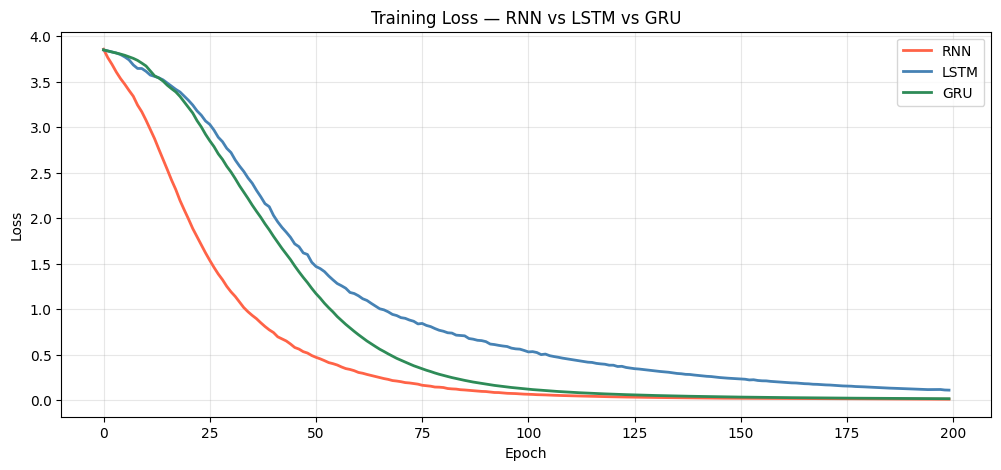

Final Loss → RNN: 0.0116 | LSTM: 0.1115 | GRU: 0.0174


In [29]:
plt.figure(figsize=(12, 5))
plt.plot(rnn_history.history['loss'],  label='RNN',  color='tomato',    linewidth=2)
plt.plot(lstm_history.history['loss'], label='LSTM', color='steelblue', linewidth=2)
plt.plot(gru_history.history['loss'],  label='GRU',  color='seagreen',  linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss — RNN vs LSTM vs GRU")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Final Loss → RNN: {rnn_history.history['loss'][-1]:.4f} | LSTM: {lstm_history.history['loss'][-1]:.4f} | GRU: {gru_history.history['loss'][-1]:.4f}")

## Section 7 — Text Generation Function

this function predicts one word at a time. it uses np.argmax to pick the word with the highest probability from the model output, then appends it to the seed and repeats.

In [30]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted_index = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                seed_text += " " + word
                break
    return seed_text

## Section 8 — Generated Text Samples

using the same seed for all three so the comparison is fair. generating 10 words (Task 5) instead of 5 — longer output makes it easier to spot where each model starts to repeat or drift.

In [31]:
seed = 'natural language'

print('RNN :', generate_text(rnn_model,  seed, next_words=10))
print('LSTM:', generate_text(lstm_model, seed, next_words=10))
print('GRU :', generate_text(gru_model,  seed, next_words=10))

RNN : natural language processing enables machines to understand human language understanding enables machines
LSTM: natural language processing enables machines to understand human language language language language
GRU : natural language processing enables machines to understand human language processing enables machines


## Conclusion

- **Vanilla RNN** is the simplest model with no gates. it passes a single hidden state forward at each step. works okay on short sequences but forgets earlier context on longer ones due to vanishing gradients. got the lowest final loss on this small corpus (0.015) but mainly because it overfits fast, not because it learned better.

- **LSTM** has three gates input, forget and output which let it decide what to keep and what to drop from memory. slower to converge than RNN (final loss 0.083 here) but would clearly win on a larger dataset where long-range context matters.

- **GRU** simplifies LSTM down to two gates reset and update. trains faster, uses less memory, and got a final loss of 0.0245. for most text generation use cases GRU is a good default close to LSTM quality, cheaper to train.

- from the loss graph all three converge differently. RNN drops fastest early on but plateaus at a shallow point. GRU converges smoothly to a low loss. LSTM is slower to stabilize but has the most capacity for complex patterns.

- generated text shows RNN repeating words after a few steps while LSTM and GRU stay more coherent. the gap would be more visible with a larger corpus on this small dataset all three models mostly memorize the sentences.